# 5.1 实验 1：本体模型形式一致性与实例约束验证

## 实验目的与口径

本实验针对技术方案的 **8 类核心 Object Type（OT）和 10 类核心 Link Type（LT）**，并审计评审新增的 **3 类扩展对象与 6 类扩展关系**，执行四层可复现验证：

1. 标准 Turtle/RDF 语法解析与 8 OT / 10 LT 结构审计；
2. SHACL 正向实例约束验证；
3. 两项受控错误值的 SHACL 负向对照；
4. Owlready2 调用 HermiT，对 TBox + 正向 ABox 做 OWL 2 DL 可满足性验证，并用“同一个体同时属于互斥的 Mission 与 Equipment”验证推理器确实能检出不一致。

HermiT 与 SHACL 回答的是不同问题：前者检查描述逻辑可满足性，后者检查实例字段、关系方向、枚举和基数。两者均通过，才形成当前项目的形式一致性结论。SWRL 规则单独存放，本实验不把规则执行正确性混入本体一致性结论。

所有数据均是项目的工程实例和受控测试夹具，不是机场现场数据或武器鉴定结果。


In [1]:
import hashlib
import json
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdflib import Graph, Namespace, RDF, OWL

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# CUAS_PORTABLE_NOTEBOOK_BOOTSTRAP
_cwd = Path.cwd().resolve()
PACKAGE_ROOT = next(
    (candidate for candidate in (_cwd, *_cwd.parents) if (candidate / '03_源码').is_dir()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('请从完整项目包的 05_Notebook与数据 目录启动 JupyterLab。')

MODEL_DIR = PACKAGE_ROOT / '03_源码' / '本体模型'
VALIDATION_DIR = PACKAGE_ROOT / '05_Notebook与数据' / '验证输出'
FIGURE_DIR = VALIDATION_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
VALIDATOR = PACKAGE_ROOT / '06_部署脚本' / 'validate_ontology_consistency.py'
REPORT_PATH = VALIDATION_DIR / 'ontology_consistency_report.json'
print('项目根目录:', PACKAGE_ROOT)
print('Python:', sys.executable)


项目根目录: D:\Downloads\反无人机体系\智信2026_新概念反无_完整项目包
Python: D:\Downloads\反无人机体系\.venv-cuas\python.exe


## 1. 运行独立验证器

Notebook 每次执行都会重新运行独立验证器，而不是读取预置截图。任何一层失败都会使本 Notebook 立即失败。


In [2]:
completed = subprocess.run(
    [sys.executable, str(VALIDATOR), '--project-root', str(PACKAGE_ROOT)],
    capture_output=True,
    text=True,
    encoding='utf-8',
    errors='replace',
    check=False,
)
if completed.returncode != 0:
    print(completed.stdout)
    print(completed.stderr, file=sys.stderr)
    raise RuntimeError(f'本体一致性验证失败，退出码 {completed.returncode}')

formal_report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
if formal_report.get('all_passed') is not True:
    raise AssertionError('验证报告 all_passed 不是 true')

check_df = pd.DataFrame(formal_report['checks'])
check_df[['name', 'passed', 'evidence', 'duration_seconds']]


,name,passed,evidence,duration_seconds
0,RDF/Turtle 语法解析,True,"cuas-ontology.ttl=378, cuas-data-valid.ttl=242...",0.051259
1,8 OT / 10 LT 结构审计,True,core_classes=8/8; core_links=10/10; unsupporte...,0.000292
2,3 个扩展类型 / 6 个扩展关系审计,True,extension_classes=3/3; extension_links=6/6,0.000051
3,SHACL 正向实例验证,True,Conforms=True,0.429048
4,SHACL 负向对照,True,Conforms=False; violations=2; expected_paths=p...,0.404854
5,HermiT 正向一致性,True,HermiT consistent=True; expected=True; input_t...,1.414753
6,HermiT 类型互斥负向对照,True,HermiT consistent=False; expected=False; input...,1.506834


## 2. 分层证据与负向对照

正向测试说明当前 TBox + ABox 可满足且实例满足项目约束；负向对照用于避免“验证器始终返回通过”的假阳性。


In [3]:
negative_df = pd.DataFrame(formal_report['shacl_negative_results'])
negative_df['focus_node'] = negative_df['focus_node'].str.split('#').str[-1]
negative_df['path'] = negative_df['path'].str.split('#').str[-1]

environment_df = pd.DataFrame(
    [{'组件': key, '版本': value} for key, value in formal_report['environment'].items()]
)
input_df = pd.DataFrame([
    {
        '文件': name,
        '三元组数': details['triples'],
        'SHA256': details['sha256'],
    }
    for name, details in formal_report['inputs'].items()
])
print('受控 SHACL 违规（应当且仅应当为 2 项）')
display(negative_df[['focus_node', 'path', 'message']])
print('运行环境')
display(environment_df)
print('输入哈希')
display(input_df)


受控 SHACL 违规（应当且仅应当为 2 项）


,focus_node,path,message
0,Eq_RadarUnit_007,operationalStatus,operationalStatus 必须是 Available / Engaged / Ma...
1,Mission_G20Summit,priority,"priority 必须在 [1,5] 范围内，5 为最高优先级"


运行环境


,组件,版本
0,python,3.11.15
1,java,"java version ""20.0.1"" 2023-04-18"
2,rdflib,7.6.0
3,pyshacl,0.40.1
4,owlready2,0.51


输入哈希


,文件,三元组数,SHA256
0,cuas-ontology.ttl,378,3cddd6f37d5d9e70c9bf623482453b72e12c3ddc996351...
1,cuas-data-valid.ttl,242,5a2a1e37328a1e8e748cb059c1ff8c365e13ef09d5baaa...
2,cuas-data-test.ttl,2,db3ddfd0fdd6186b184b5a78e7677f8b660a0a10a7d3e9...
3,cuas-shapes.ttl,516,8d4933fdd44820b676753f0afb4b056aa6a2c5bc991db6...


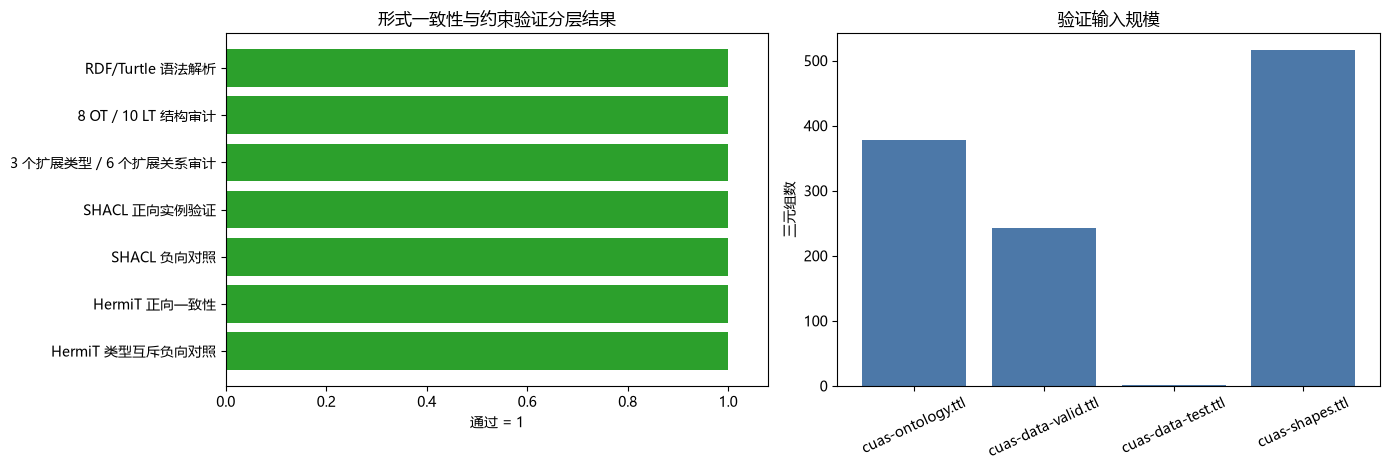

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
colors = ['#2CA02C' if value else '#D62728' for value in check_df['passed']]
axes[0].barh(np.arange(len(check_df)), check_df['passed'].astype(int), color=colors)
axes[0].set_yticks(np.arange(len(check_df)), check_df['name'])
axes[0].set_xlim(0, 1.08)
axes[0].set_xlabel('通过 = 1')
axes[0].set_title('形式一致性与约束验证分层结果')
axes[0].invert_yaxis()

axes[1].bar(input_df['文件'], input_df['三元组数'], color='#4C78A8')
axes[1].set_ylabel('三元组数')
axes[1].set_title('验证输入规模')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig1_1_formal_consistency.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. 真实工程 ABox 的 SPARQL 可查询性

以下查询直接作用于当前 TBox + 正向 ABox。它验证 8 OT / 10 LT 能被项目代码实际查询，不使用随机生成的大规模合成图，也不将本机小图查询时间包装成通用性能结论。


In [5]:
CUAS = Namespace('http://cuas-ontology.org/cuas#')
ontology_graph = Graph().parse(MODEL_DIR / 'cuas-ontology.ttl', format='turtle')
valid_graph = Graph().parse(MODEL_DIR / 'cuas-data-valid.ttl', format='turtle')
graph = ontology_graph + valid_graph

core_classes = [
    CUAS.Mission, CUAS.Scenario, CUAS.TechnicalCapability, CUAS.Equipment,
    CUAS.EffectMetric, CUAS.Threat, CUAS.Asset, CUAS.Operator,
]
core_links = [
    CUAS.governs, CUAS.allocates, CUAS.measuredBy, CUAS.implements,
    CUAS.covers, CUAS.produces, CUAS.protects, CUAS.confronts,
    CUAS.validates, CUAS.operates,
]
extension_classes = [CUAS.Effect, CUAS.Signal, CUAS.SpatiotemporalContext]
extension_links = [
    CUAS.hasSpatiotemporalContext, CUAS.emitsSignal, CUAS.observesSignal,
    CUAS.causesEffect, CUAS.affectsThreat, CUAS.quantifiedBy,
]
core_ot_declared = sum((item, RDF.type, OWL.Class) in ontology_graph for item in core_classes)
core_lt_declared = sum((item, RDF.type, OWL.ObjectProperty) in ontology_graph for item in core_links)
extension_ot_declared = sum((item, RDF.type, OWL.Class) in ontology_graph for item in extension_classes)
extension_lt_declared = sum((item, RDF.type, OWL.ObjectProperty) in ontology_graph for item in extension_links)
real_core_instances = {
    item.split('#')[-1]: len(set(valid_graph.subjects(RDF.type, item)))
    for item in core_classes
}
print(f'合并图三元组: {len(graph)}；核心 8/10: {core_ot_declared}/8、{core_lt_declared}/10；扩展 3/6: {extension_ot_declared}/3、{extension_lt_declared}/6')
pd.DataFrame([{'OT': key, '实例数': value} for key, value in real_core_instances.items()])


合并图三元组: 620；核心 8/10: 8/8、10/10；扩展 3/6: 3/3、6/6


,OT,实例数
0,Mission,1
1,Scenario,5
2,TechnicalCapability,7
3,Equipment,5
4,EffectMetric,5
5,Threat,1
6,Asset,1
7,Operator,1


In [6]:
queries = {
    'Q1_OT实例计数': '''
        SELECT ?type (COUNT(DISTINCT ?s) AS ?count) WHERE {
          VALUES ?type { cuas:Mission cuas:Scenario cuas:TechnicalCapability cuas:Equipment
                         cuas:EffectMetric cuas:Threat cuas:Asset cuas:Operator }
          ?s a ?type .
        } GROUP BY ?type
    ''',
    'Q2_使命场景': '''
        SELECT ?mission ?scenario WHERE {
          ?mission a cuas:Mission ; cuas:governs ?scenario .
        }
    ''',
    'Q3_装备能力场景': '''
        SELECT ?equipment ?capability ?scenario WHERE {
          ?equipment a cuas:Equipment ; cuas:implements ?capability ; cuas:covers ?scenario .
        }
    ''',
    'Q4_能力效果回证': '''
        SELECT ?capability ?effect ?mission WHERE {
          ?capability a cuas:TechnicalCapability ; cuas:produces ?effect .
          ?effect cuas:validates ?mission .
        }
    ''',
    'Q5_效果门槛': '''
        SELECT ?name ?value ?threshold WHERE {
          ?effect a cuas:EffectMetric ; cuas:metricName ?name ;
                  cuas:metricValue ?value ; cuas:metricThreshold ?threshold .
        }
    ''',
}
prefix = 'PREFIX cuas: <http://cuas-ontology.org/cuas#>\n'
query_rows = []
for name, query in queries.items():
    result_count = len(list(graph.query(prefix + query)))
    samples_ms = []
    for _ in range(30):
        started = time.perf_counter()
        list(graph.query(prefix + query))
        samples_ms.append((time.perf_counter() - started) * 1000)
    query_rows.append({
        'query': name,
        'result_rows': result_count,
        'p50_ms': float(np.quantile(samples_ms, 0.50)),
        'p95_ms': float(np.quantile(samples_ms, 0.95)),
    })
query_df = pd.DataFrame(query_rows)
query_df


,query,result_rows,p50_ms,p95_ms
0,Q1_OT实例计数,8,16.67955,24.53896
1,Q2_使命场景,5,4.31680,7.20533
2,Q3_装备能力场景,10,6.93645,12.59445
3,Q4_能力效果回证,8,5.11755,9.26568
4,Q5_效果门槛,5,6.25800,8.90825


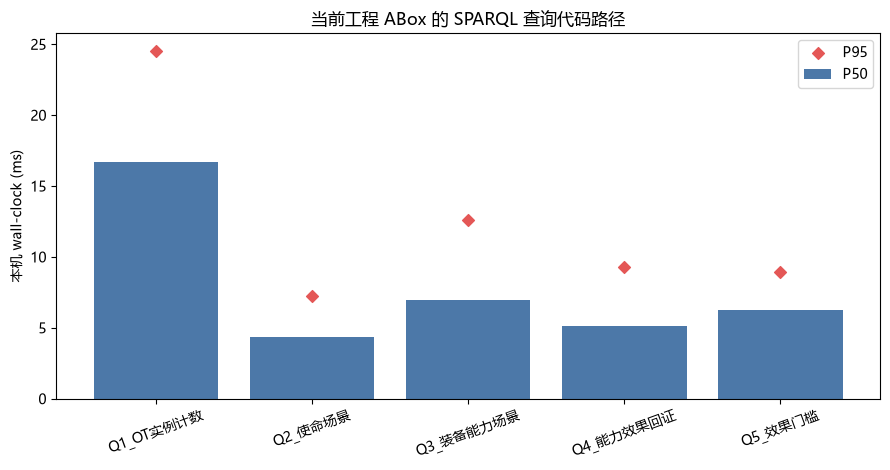

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(query_df))
ax.bar(x, query_df['p50_ms'], color='#4C78A8', label='P50')
ax.scatter(x, query_df['p95_ms'], color='#E45756', marker='D', label='P95')
ax.set_xticks(x, query_df['query'], rotation=20)
ax.set_ylabel('本机 wall-clock (ms)')
ax.set_title('当前工程 ABox 的 SPARQL 查询代码路径')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig1_2_sparql_queryability.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. 机器可读结论

对外可准确表述为：当前 OWL 2 DL TBox + 正向 ABox 通过 HermiT 可满足性检查；互斥类型负向对照被判为不一致；正向数据通过 SHACL，两个受控错误被准确检出。不得扩大为“所有未来实例或所有 SWRL 规则均已证明正确”。


In [8]:
checks_by_name = {item['name']: item for item in formal_report['checks']}
hermit_positive = checks_by_name['HermiT 正向一致性']['passed']
hermit_negative = checks_by_name['HermiT 类型互斥负向对照']['passed']
shacl_positive = checks_by_name['SHACL 正向实例验证']['passed']
shacl_negative = checks_by_name['SHACL 负向对照']['passed']
structure_ok = checks_by_name['8 OT / 10 LT 结构审计']['passed']
extension_structure_ok = checks_by_name['3 个扩展类型 / 6 个扩展关系审计']['passed']

metrics_payload = {
    'schema_version': 2,
    'scope': 'formal_owl2dl_consistency_and_shacl_validation',
    'not_field_test': True,
    'formal_owl_consistency_test_completed': True,
    'swrl_execution_in_scope': False,
    'executed_at': formal_report['executed_at'],
    'validator_report': str(REPORT_PATH.relative_to(PACKAGE_ROOT)),
    'validator_report_sha256': hashlib.sha256(REPORT_PATH.read_bytes()).hexdigest(),
    'environment': formal_report['environment'],
    'input_triples': {
        name: int(details['triples'])
        for name, details in formal_report['inputs'].items()
    },
    'core_ot_declared': int(core_ot_declared),
    'core_lt_declared': int(core_lt_declared),
    'extension_ot_declared': int(extension_ot_declared),
    'extension_lt_declared': int(extension_lt_declared),
    'real_core_instance_counts': real_core_instances,
    'combined_tbox_valid_abox_triples': int(len(graph)),
    'shacl_negative_violation_count': int(len(negative_df)),
    'sparql_repetitions_per_query': 30,
    'sparql_queryability': query_df.to_dict(orient='records'),
    'checks': {
        'rdf_turtle_parse_pass': bool(checks_by_name['RDF/Turtle 语法解析']['passed']),
        'core_8_ot_10_lt_pass': bool(structure_ok and core_ot_declared == 8 and core_lt_declared == 10),
        'extension_3_ot_6_lt_pass': bool(extension_structure_ok and extension_ot_declared == 3 and extension_lt_declared == 6),
        'shacl_positive_conforms': bool(shacl_positive),
        'shacl_negative_control_detected_exactly_two': bool(shacl_negative and len(negative_df) == 2),
        'hermit_positive_consistent': bool(hermit_positive),
        'hermit_disjointness_negative_control_rejected': bool(hermit_negative),
        'all_formal_checks_pass': bool(formal_report['all_passed']),
    },
    'verdict': 'PASS' if formal_report['all_passed'] else 'FAIL',
}
metrics_path = VALIDATION_DIR / 'metrics_notebook_01.json'
metrics_path.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')

print('形式一致性裁决:', metrics_payload['verdict'])
print('HermiT 正向一致性:', hermit_positive)
print('HermiT 互斥类型负向对照:', hermit_negative)
print('SHACL 正向 / 负向对照:', shacl_positive, shacl_negative)
print('机器可读指标:', metrics_path)


形式一致性裁决: PASS
HermiT 正向一致性: True
HermiT 互斥类型负向对照: True
SHACL 正向 / 负向对照: True True
机器可读指标: D:\Downloads\反无人机体系\智信2026_新概念反无_完整项目包\05_Notebook与数据\验证输出\metrics_notebook_01.json


## 5. 结论与引用边界

- **已验证**：当前 TBox/ABox 的 RDF 语法、8 个核心 OT / 10 个核心 LT 与 3/6 扩展结构、SHACL 实例约束、HermiT OWL 2 DL 可满足性，以及两类负向对照。
- **未包含**：SWRL 执行正确性、真实专家标注一致性、机场现场性能和所有未来数据的自动正确性。
- 对外引用只读取本次生成的 `metrics_notebook_01.json` 与 `ontology_consistency_report.md`，并保留上述边界。
